# Data and Libraries

In [1]:
!sudo apt install -qq aria2
!aria2c -x 16 -s 16 -k 1M "http://128.32.162.150/bdd100k/bdd100k_seg_maps.zip"
!aria2c -x 16 -s 16 -k 1M "http://128.32.162.150/bdd100k/bdd100k_images_10k.zip"

!unzip -q /content/bdd100k_images_10k.zip
!unzip -q /content/bdd100k_seg_maps.zip

!pip install segmentation-models-pytorch torchmetrics wandb -q

The following additional packages will be installed:
  libaria2-0 libc-ares2
The following NEW packages will be installed:
  aria2 libaria2-0 libc-ares2
0 upgraded, 3 newly installed, 0 to remove and 53 not upgraded.
Need to get 1,513 kB of archives.
After this operation, 5,441 kB of additional disk space will be used.
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 3.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package libc-ares2:amd64.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../libc-ares2_1.18.1-1ubuntu0.22.04.3_amd64.deb ...
Unpacking libc-ares2:amd64

In [2]:
# Standard library imports
from datetime import datetime
from pathlib import Path
import random

# Core data and visualization
import cv2
import matplotlib.pyplot as plt
import numpy as np

# PyTorch core and data
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from transformers import AutoImageProcessor, SegformerForSemanticSegmentation

# Modeling and augmentations
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# Metrics
from torchmetrics import JaccardIndex
from torchmetrics.classification import MulticlassJaccardIndex
from torchmetrics.segmentation import MeanIoU
from torch.optim.lr_scheduler import CosineAnnealingLR
import wandb

# Dataset, Augmentations, and Model Initialization
- Removes 8 bad IDs
- Horizontal Flip, Color Jitter, and Affine


In [3]:
# Gloabl vars
lr = 1e-3
encoder = 'efficientnet-b4'
encoder_weights = 'imagenet'
batch_size = 32
num_epochs = 50
patience = 7

RESIZE_IMGS = True
LOAD_BEST_MODEL = False

best_miou = 0
epochs_no_improve = 0
best_model_path = '/content/drive/MyDrive/best_bdd100k_unet.pth'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

# Model Initialization
model = smp.Unet(
    encoder_name=encoder,
    encoder_weights=encoder_weights,
    in_channels=3,
    classes=19
    ).to(device)

if LOAD_BEST_MODEL:
    model.load_state_dict(torch.load(best_model_path, map_location=device))

# Loss configuration
focal_crit = smp.losses.FocalLoss(mode='multiclass', ignore_index=255)
dice_crit = smp.losses.DiceLoss(mode='multiclass', ignore_index=255)

# Optimizer and scheduler configuration
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

# Encoder preprocessing parameters
params = smp.encoders.get_preprocessing_params(encoder, encoder_weights)

# Scoring
miou = JaccardIndex(task='multiclass', num_classes=19, ignore_index=255).to(device)

cuda


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

In [4]:
!wandb login

# Start a new wandb run to track this script.
run = wandb.init(
    entity="calebkreed26-tesla",
    project="BDD100k Model Comparison",
    config={
        "learning_rate": lr,
        "encoder": encoder,
        "encoder_weights": encoder_weights,
        "batch_size": batch_size,
        "architecture": "U-Net",
        "dataset": "BDD100k",
        "image_resolution": 720,
        "max_epochs": num_epochs,
        "patience": 7,
    },
)

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: calebkreed26 (calebkreed26-tesla) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: calebkreed26 (calebkreed26-tesla) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
class CustomDataset(Dataset):
    BAD_IDS = ['781756b0-61e0a182', '3d581db5-2564fb7e', '52e3fd10-c205dec2', '78ac84ba-07bd30c2', '9342e334-33d167eb', '80a9e37d-e4548ac1']

    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.transform = transform

        # build list of valid pairs by matching stems
        self.pairs = []

        for f in self.image_dir.glob('*.jpg'):
            if f.stem in self.BAD_IDS:
                continue
            label_path = self.label_dir / f'{f.stem}_train_id.png'
            if label_path.exists():
                self.pairs.append((f, label_path))

        print(f"Preloading {len(self.pairs)} samples...")
        self.images = []
        self.labels = []
        for img_path, label_path in self.pairs:
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            label = cv2.imread(str(label_path), cv2.IMREAD_GRAYSCALE)
            self.images.append(img)
            self.labels.append(label)
        print("Done.")

    def __len__(self):
        return len(self.pairs)  # tells PyTorch how many samples we have

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            augmented = self.transform(image=img, mask=label)
            img, label = augmented['image'], augmented['mask']

        label = label.long()
        return img, label

In [6]:
transforms = []
if RESIZE_IMGS:
    transforms.append(A.Resize(360, 640))
transforms.append(A.Normalize(mean=params["mean"], std=params["std"]))
transforms.append(ToTensorV2())

base_transform = A.Compose(transforms)

transforms = []
if RESIZE_IMGS:
    transforms.append(A.Resize(360, 640))
transforms.append(A.HorizontalFlip(p=0.5))
transforms.append(A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, p=0.5))
transforms.append(A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-10, 10), p=0.5))
transforms.append(A.Normalize(mean=params["mean"], std=params["std"]))
transforms.append(ToTensorV2())

train_transform = A.Compose(transforms)

train_dataset = CustomDataset('/content/10k/train', '/content/labels/train', transform=train_transform)
val_dataset = CustomDataset('/content/10k/val', '/content/labels/val', transform=base_transform)

print(f'Training Dataset: {len(train_dataset)} Pairs\nVal Dataset: {len(val_dataset)} Pairs')

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)

Preloading 6996 samples...
Done.
Preloading 998 samples...
Done.
Training Dataset: 6996 Pairs
Val Dataset: 998 Pairs


# Training Loop U-Net

In [7]:
# Training loop
print('Starting Training...')
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for img, label in train_loader:
        img, label = img.to(device), label.to(device)
        optimizer.zero_grad()
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            prediction = model(img)
            loss = focal_crit(prediction, label) + dice_crit(prediction, label)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for img, label in val_loader:
            img, label = img.to(device), label.to(device)
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                prediction = model(img)
                loss = focal_crit(prediction, label) + dice_crit(prediction, label)
            val_loss += loss.item()
            miou.update(prediction.argmax(dim=1), label)

    avg_val_loss = val_loss / len(val_loader)
    avg_train_loss = train_loss / len(train_loader)
    epoch_miou = miou.compute()
    miou.reset()

    # Best Model Saving
    if epoch_miou > best_miou:
        epochs_no_improve = 0
        best_miou = epoch_miou
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1

    # W&D logging
    run.log({
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "miou": epoch_miou,
        "best_score": best_miou,
        "epoch": epoch,
        "epochs_no_improve": epochs_no_improve
    })

    # LR Scheduler
    scheduler.step()

    print(f'{datetime.now()} - Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Best Score: {best_miou:.4f}, MIOU: {epoch_miou:.4f}')

    # Early Stop Checker
    if epochs_no_improve > patience:
        print(f'No improvement in {patience} epochs, stopping...')
        break

Starting Training...
2026-06-22 18:59:07.751685 - Epoch 1/50 - Train Loss: 1.2473, Val Loss: 0.9002, Best Score: 0.2476, MIOU: 0.2476
2026-06-22 19:01:20.067250 - Epoch 2/50 - Train Loss: 0.9205, Val Loss: 0.8330, Best Score: 0.2885, MIOU: 0.2885
2026-06-22 19:03:32.366285 - Epoch 3/50 - Train Loss: 0.8716, Val Loss: 0.7963, Best Score: 0.3199, MIOU: 0.3199
2026-06-22 19:05:45.021235 - Epoch 4/50 - Train Loss: 0.8303, Val Loss: 0.7575, Best Score: 0.3607, MIOU: 0.3607
2026-06-22 19:07:57.442227 - Epoch 5/50 - Train Loss: 0.7915, Val Loss: 0.7426, Best Score: 0.3691, MIOU: 0.3691
2026-06-22 19:10:09.751324 - Epoch 6/50 - Train Loss: 0.7480, Val Loss: 0.6978, Best Score: 0.4143, MIOU: 0.4143
2026-06-22 19:12:22.138926 - Epoch 7/50 - Train Loss: 0.7300, Val Loss: 0.6710, Best Score: 0.4464, MIOU: 0.4464
2026-06-22 19:14:34.459417 - Epoch 8/50 - Train Loss: 0.7039, Val Loss: 0.6368, Best Score: 0.4584, MIOU: 0.4584
2026-06-22 19:16:46.482869 - Epoch 9/50 - Train Loss: 0.6759, Val Loss: 0.7

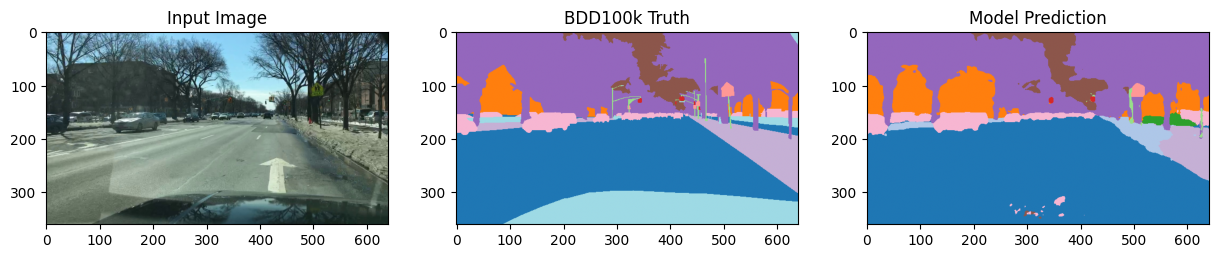

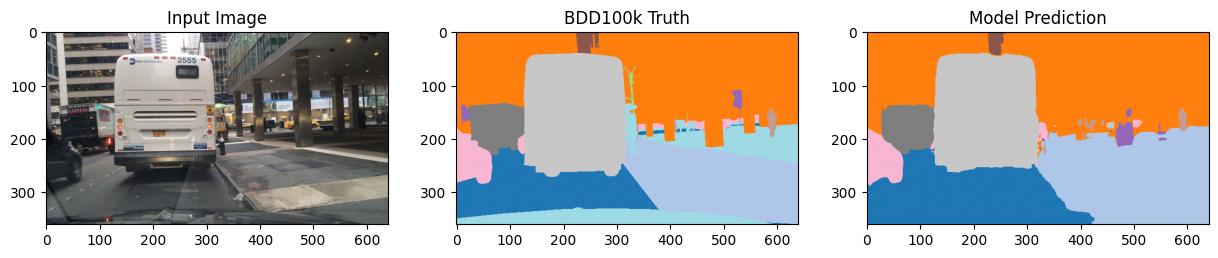

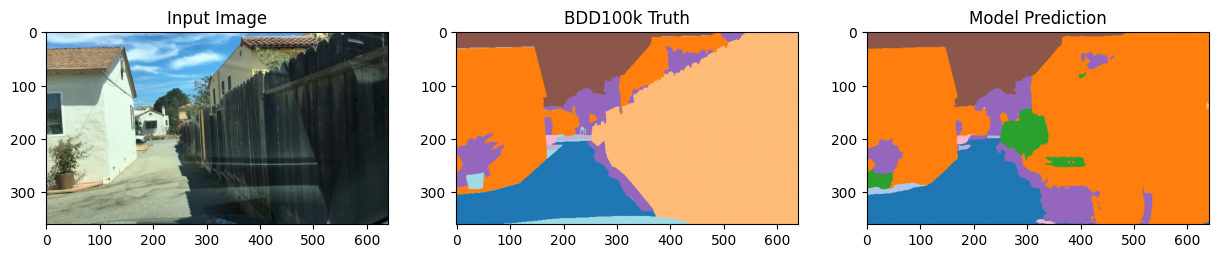

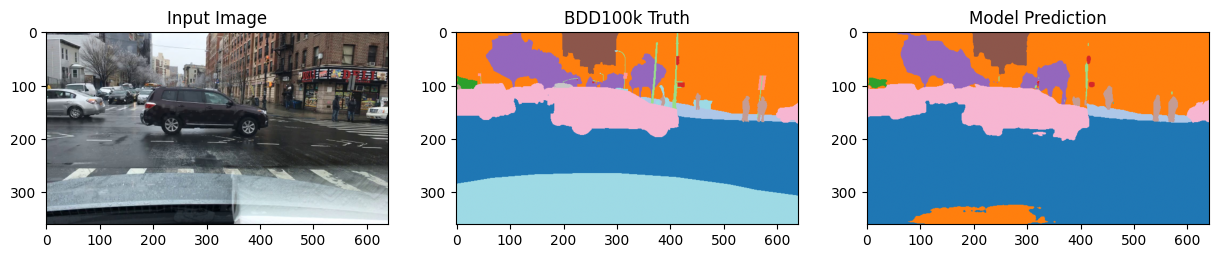

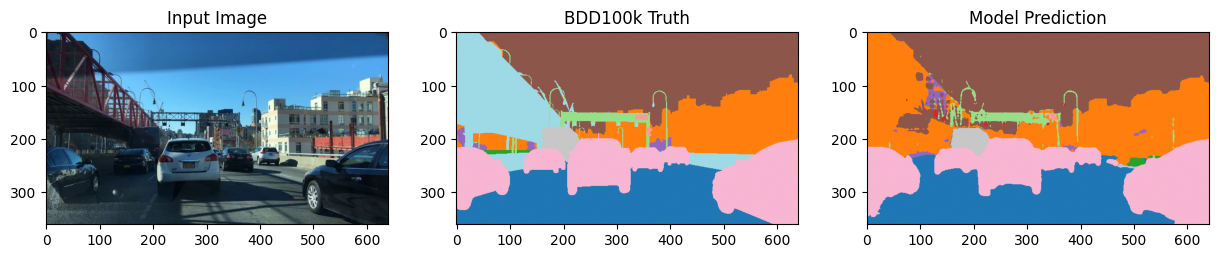

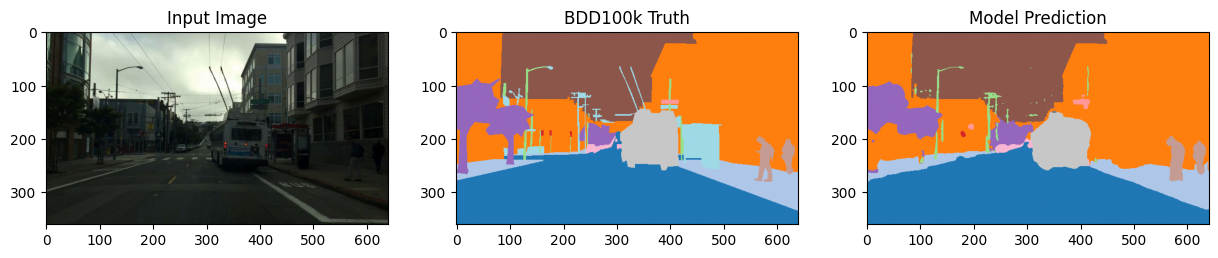

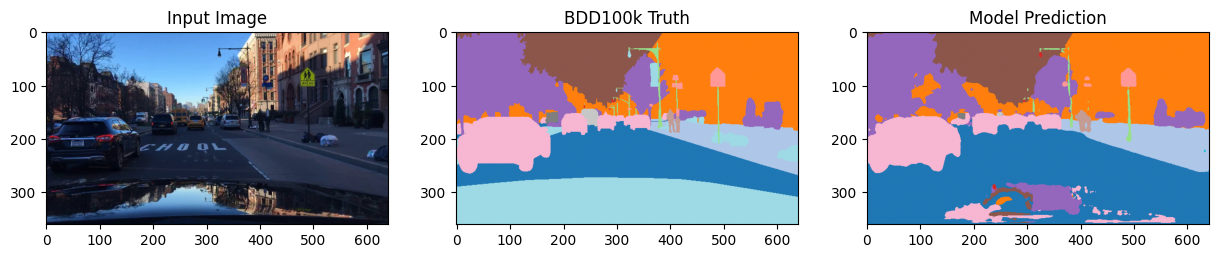

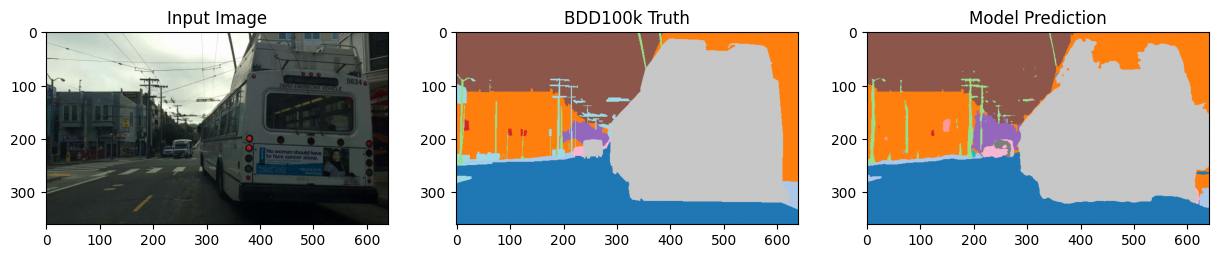

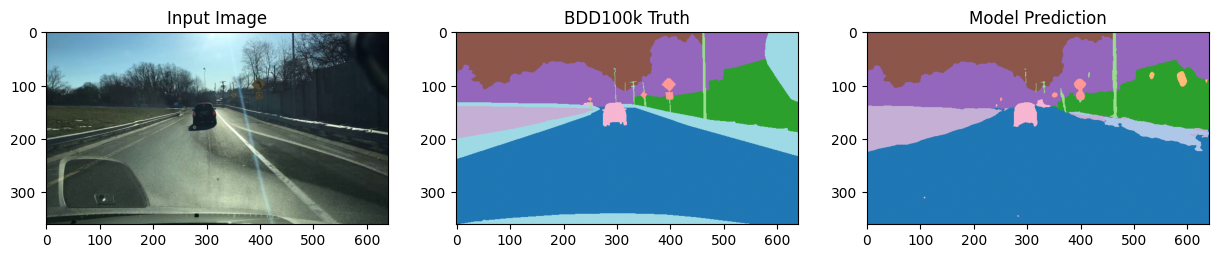

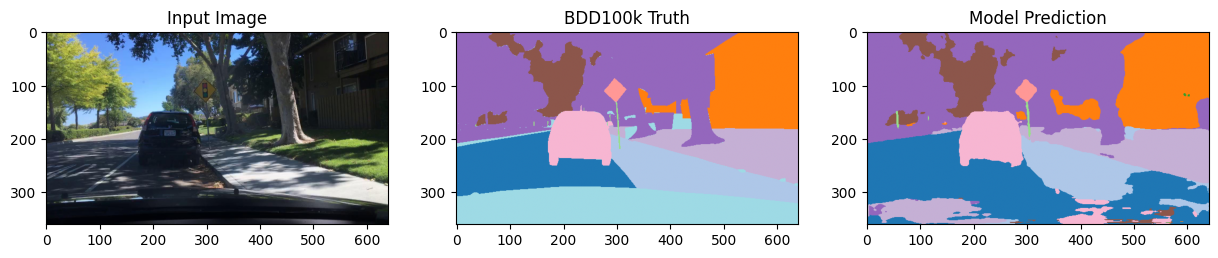

In [8]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

for n in range(10, 20):
    img, label = val_loader.dataset[n]

    in_img = img.unsqueeze(0)
    in_img = in_img.to(device)
    prediction = model(in_img)

    prediction = prediction.argmax(dim=1)
    prediction = prediction.squeeze(0)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_np = (img * std + mean).permute(1, 2, 0).numpy().clip(0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_np)  # original
    axes[0].set_title('Input Image')

    axes[1].imshow(label, vmin=0, vmax=19, cmap='tab20')
    axes[1].set_title('BDD100k Truth')

    axes[2].imshow(prediction.cpu(), vmin=0, vmax=19, cmap='tab20')  # model prediction
    axes[2].set_title('Model Prediction')

    plt.show()

0.59145814


/tmp/ipykernel_9250/1011053752.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_names, rotation=45, ha='right')
/tmp/ipykernel_9250/1011053752.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


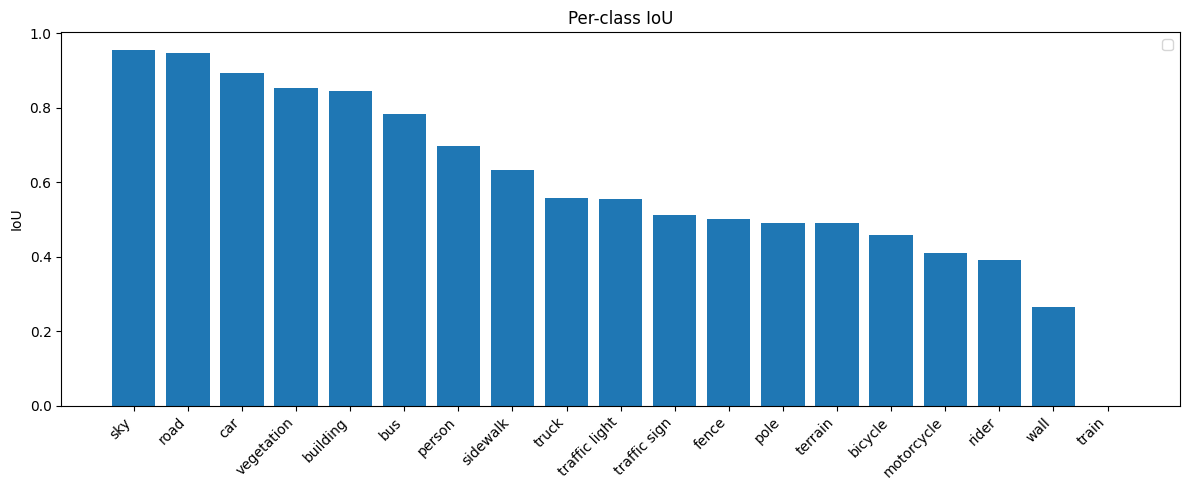

In [9]:
metric = MulticlassJaccardIndex(num_classes=19, average=None, ignore_index=255).to(device)

model.eval()
val_loss = 0
with torch.no_grad():
    for img, label in val_loader:
        img, label = img.to(device), label.to(device)
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            prediction = model(img)
        metric.update(prediction.argmax(dim=1), label)

per_class_miou = metric.compute().cpu().numpy()

class_names = ['road', 'sidewalk', 'building', 'wall', 'fence', 'pole',
               'traffic light', 'traffic sign', 'vegetation', 'terrain',
               'sky', 'person', 'rider', 'car', 'truck', 'bus',
               'train', 'motorcycle', 'bicycle']

indices = per_class_miou.argsort()[::-1]
sorted_iou = per_class_miou[indices]
sorted_names = [class_names[i] for i in indices]

print(per_class_miou.mean())

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(sorted_names, sorted_iou)
ax.set_xticklabels(sorted_names, rotation=45, ha='right')
ax.set_ylabel('IoU')
ax.set_title('Per-class IoU')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()